# Розпізнавання жестів: Лабораторна робота №1

## Постановка задачі

Об'єктом дослідження є зображення руки, що представляє певний жест. У рамках цієї роботи жест описується вектором ознак у двовимірному просторі. Вхідні параметри: висота та ширина долоні.

Головним завданням є генерація синтетичної вибірки для базових класів (кулак та долоня) та реалізація класифікатора. Наступним етапом є аналіз можливості розширення простору ознак третім класом (знак перемоги) та оцінка якості кластеризації отриманих даних.

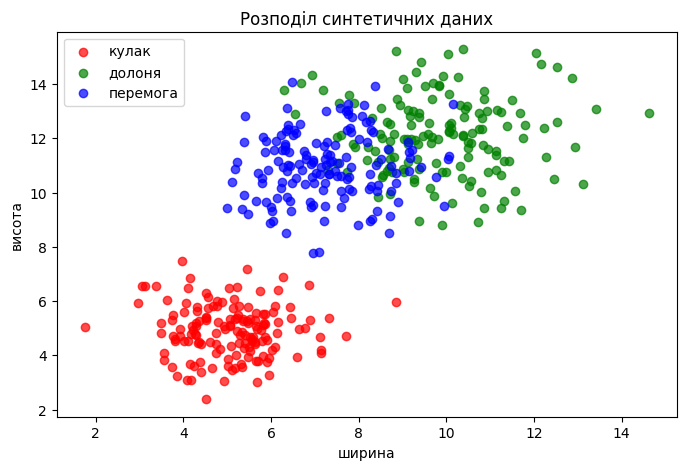

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# налаштування генератора випадкових чисел для відтворюваності
np.random.seed(42)

def generate_data(n_samples=100):
    """
    Генерує синтетичні дані для трьох класів жестів.
    """
    # клас 0: кулак (компактний об'єкт)
    fist_h = np.random.normal(loc=5, scale=1.0, size=n_samples)
    fist_w = np.random.normal(loc=5, scale=1.0, size=n_samples)

    # клас 1: долоня (розгорнуті пальці)
    palm_h = np.random.normal(loc=12, scale=1.5, size=n_samples)
    palm_w = np.random.normal(loc=10, scale=1.5, size=n_samples)

    # клас 2: знак перемоги (V-подібний жест)
    victory_h = np.random.normal(loc=11, scale=1.2, size=n_samples)
    victory_w = np.random.normal(loc=7, scale=1.2, size=n_samples)

    # формування масивів
    X_fist = np.column_stack((fist_w, fist_h))
    X_palm = np.column_stack((palm_w, palm_h))
    X_victory = np.column_stack((victory_w, victory_h))

    # базовий набір (2 класи)
    X_base = np.vstack((X_fist, X_palm))
    y_base = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

    # розширений набір (3 класи)
    X_ext = np.vstack((X_base, X_victory))
    y_ext = np.hstack((y_base, np.full(n_samples, 2)))

    return X_base, y_base, X_ext, y_ext

X_base, y_base, X_ext, y_ext = generate_data(150)

plt.figure(figsize=(8, 5))
plt.scatter(X_ext[y_ext==0][:,0], X_ext[y_ext==0][:,1], color='red', label='кулак', alpha=0.7)
plt.scatter(X_ext[y_ext==1][:,0], X_ext[y_ext==1][:,1], color='green', label='долоня', alpha=0.7)
plt.scatter(X_ext[y_ext==2][:,0], X_ext[y_ext==2][:,1], color='blue', label='перемога', alpha=0.7)
plt.xlabel('ширина')
plt.ylabel('висота')
plt.title('Розподіл синтетичних даних')
plt.legend()
plt.show()

## Реалізація методу k-найближчих сусідів

Для розділення класів реалізовано алгоритм k-NN без використання сторонніх бібліотек машинного навчання. Алгоритм обчислює евклідову відстань між точкою запиту та всіма точками тренувального набору, обирає k найближчих сусідів та визначає клас шляхом голосування.

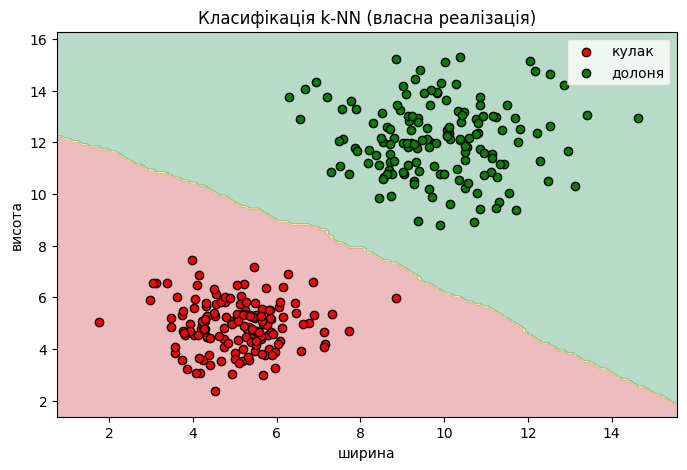

In [2]:
class SimpleKNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        predictions = []
        for x in X_test:
            # обчислення евклідових відстаней
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            # отримання індексів k найближчих сусідів
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            # голосування
            labels, counts = np.unique(k_nearest_labels, return_counts=True)
            predictions.append(labels[np.argmax(counts)])
        return np.array(predictions)

# тренування та візуалізація
knn = SimpleKNN(k=5)
knn.fit(X_base, y_base)

h = .1
x_min, x_max = X_base[:, 0].min() - 1, X_base[:, 0].max() + 1
y_min, y_max = X_base[:, 1].min() - 1, X_base[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)
plt.scatter(X_base[y_base==0][:,0], X_base[y_base==0][:,1], c='red', edgecolor='k', label='кулак')
plt.scatter(X_base[y_base==1][:,0], X_base[y_base==1][:,1], c='green', edgecolor='k', label='долоня')
plt.title('Класифікація k-NN (власна реалізація)')
plt.xlabel('ширина')
plt.ylabel('висота')
plt.legend()
plt.show()

## Кластеризація та аналіз метрик

На даному етапі виконується кластеризація розширеного набору даних методом K-means, який також реалізовано вручну. Метою є знаходження оптимальної кількості кластерів для трьох типів жестів. Оцінка якості проводиться за допомогою коефіцієнта силуету (Silhouette Score) та індексу Девіса-Болдіна (Davies-Bouldin Index).

k     | Silhouette | DBI       
------------------------------
2     | 0.6574     | 0.4489
3     | 0.5111     | 0.7699
4     | 0.3669     | 1.1055
5     | 0.4803     | 0.7727
6     | 0.3707     | 0.9307


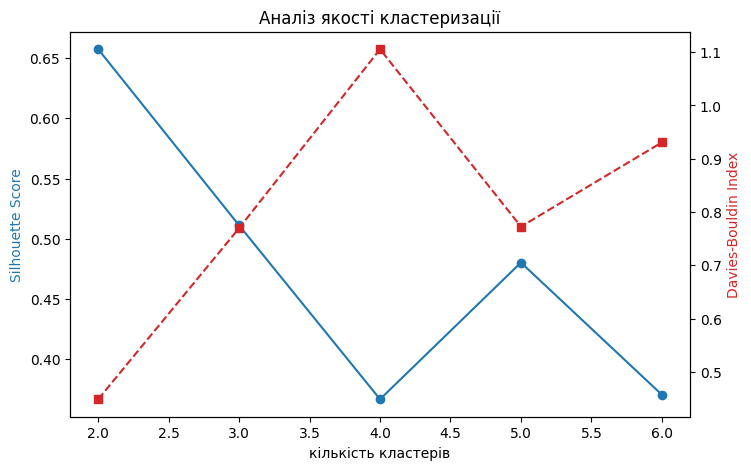

In [3]:
class SimpleKMeans:
    def __init__(self, n_clusters, max_iters=100, tol=1e-4):
        self.k = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None

    def fit_predict(self, X):
        # ініціалізація центроїдів випадковим чином
        indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[indices]

        for _ in range(self.max_iters):
            # призначення кластерів
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            # оновлення центроїдів
            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.k)])

            # перевірка на збіжність
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break
            self.centroids = new_centroids

        return labels

def calculate_silhouette(X, labels):
    """Власна реалізація Silhouette Score."""
    n = len(X)
    silhouette_vals = []

    for i in range(n):
        cluster_i = labels[i]
        # середня відстань до точок свого кластера (a)
        own_cluster = X[labels == cluster_i]
        if len(own_cluster) > 1:
            a = np.mean(np.linalg.norm(own_cluster - X[i], axis=1))
        else:
            a = 0

        # середня відстань до найближчого іншого кластера (b)
        other_clusters = np.unique(labels[labels != cluster_i])
        b_vals = []
        for c in other_clusters:
            other_cluster = X[labels == c]
            b_vals.append(np.mean(np.linalg.norm(other_cluster - X[i], axis=1)))

        b = min(b_vals) if b_vals else 0

        s = (b - a) / max(a, b) if max(a, b) > 0 else 0
        silhouette_vals.append(s)

    return np.mean(silhouette_vals)

def calculate_dbi(X, labels, centroids):
    """Власна реалізація Davies-Bouldin Index."""
    k = len(centroids)
    clusters = [X[labels == i] for i in range(k)]

    # середній розкид всередині кластера
    s = [np.mean(np.linalg.norm(c - centroids[i], axis=1)) if len(c) > 0 else 0 for i, c in enumerate(clusters)]

    max_ratios = []
    for i in range(k):
        ratios = []
        for j in range(k):
            if i != j:
                dist = np.linalg.norm(centroids[i] - centroids[j])
                if dist > 0:
                    ratios.append((s[i] + s[j]) / dist)
        if ratios:
            max_ratios.append(max(ratios))
        else:
            max_ratios.append(0)

    return np.mean(max_ratios)

# розрахунок метрик для різної кількості кластерів
cluster_range = range(2, 7)
sil_scores = []
dbi_scores = []

print(f"{'k':<5} | {'Silhouette':<10} | {'DBI':<10}")
print("-"*30)

for k in cluster_range:
    kmeans = SimpleKMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_ext)

    sil = calculate_silhouette(X_ext, labels)
    dbi = calculate_dbi(X_ext, labels, kmeans.centroids)

    sil_scores.append(sil)
    dbi_scores.append(dbi)
    print(f"{k:<5} | {sil:.4f}     | {dbi:.4f}")

# побудова графіків метрик
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('кількість кластерів')
ax1.set_ylabel('Silhouette Score', color='tab:blue')
ax1.plot(cluster_range, sil_scores, marker='o', color='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Davies-Bouldin Index', color='tab:red')
ax2.plot(cluster_range, dbi_scores, marker='s', linestyle='--', color='tab:red')

plt.title('Аналіз якості кластеризації')
plt.show()

## Висновки

Проведений аналіз метрик демонструє, що при додаванні третього класу якість розбиття може знижуватися. Значення Silhouette Score зменшується, а DBI зростає при збільшенні кількості кластерів понад два. Це свідчить про те, що у поточному просторі ознак (лише ширина та висота) класи "долоня" та "знак перемоги" мають значне перекриття.

Оптимальним рішенням для покращення якості розпізнавання є введення додаткових геометричних ознак: кількість піднятих пальців, відношення площі до опуклої оболонки або компактність фігури.